**Sentiment Analysis Exercise**

The goal of the Sentiment Analysis (SA) task is to classify the sentiment within a piece of text.

This sentiment can be either binary (positive-negative) or multi-class (a rating scale from 1 to 5).

Data: http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Digital_Music_5.json.gz

# Load data into pandas DataFrame

In [18]:
import gdown
import pandas as pd

url = "http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Digital_Music_5.json.gz"
file_name = "reviews"
gdown.download(url, file_name + ".gz")

df = pd.read_json(file_name + ".gz", compression='gzip', lines=True)

Downloading...
From: http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Digital_Music_5.json.gz
To: /content/reviews.gz
100%|██████████| 32.1M/32.1M [00:01<00:00, 16.7MB/s]


In [19]:
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A3EBHHCZO6V2A4,5555991584,"Amaranth ""music fan""","[3, 3]","It's hard to believe ""Memory of Trees"" came ou...",5,Enya's last great album,1158019200,"09 12, 2006"
1,AZPWAXJG9OJXV,5555991584,bethtexas,"[0, 0]","A clasically-styled and introverted album, Mem...",5,Enya at her most elegant,991526400,"06 3, 2001"
2,A38IRL0X2T4DPF,5555991584,bob turnley,"[2, 2]",I never thought Enya would reach the sublime h...,5,The best so far,1058140800,"07 14, 2003"
3,A22IK3I6U76GX0,5555991584,Calle,"[1, 1]",This is the third review of an irish album I w...,5,Ireland produces good music.,957312000,"05 3, 2000"
4,A1AISPOIIHTHXX,5555991584,"Cloud ""...""","[1, 1]","Enya, despite being a successful recording art...",4,4.5; music to dream to,1200528000,"01 17, 2008"


# Data exploration

Even though the task mainly focus on semantic analysis, I want to analyse whether the dataset has some interesting insights about culture, trends, ..., that can affect model's performance

In [20]:
# Drop unuseful features
df = df.drop(columns= ['reviewerID', 'reviewerName', 'helpful', 'unixReviewTime', 'reviewTime'])

In [21]:
df.head()

,asin,reviewText,overall,summary
0,5555991584,"It's hard to believe ""Memory of Trees"" came ou...",5,Enya's last great album
1,5555991584,"A clasically-styled and introverted album, Mem...",5,Enya at her most elegant
2,5555991584,I never thought Enya would reach the sublime h...,5,The best so far
3,5555991584,This is the third review of an irish album I w...,5,Ireland produces good music.
4,5555991584,"Enya, despite being a successful recording art...",4,4.5; music to dream to


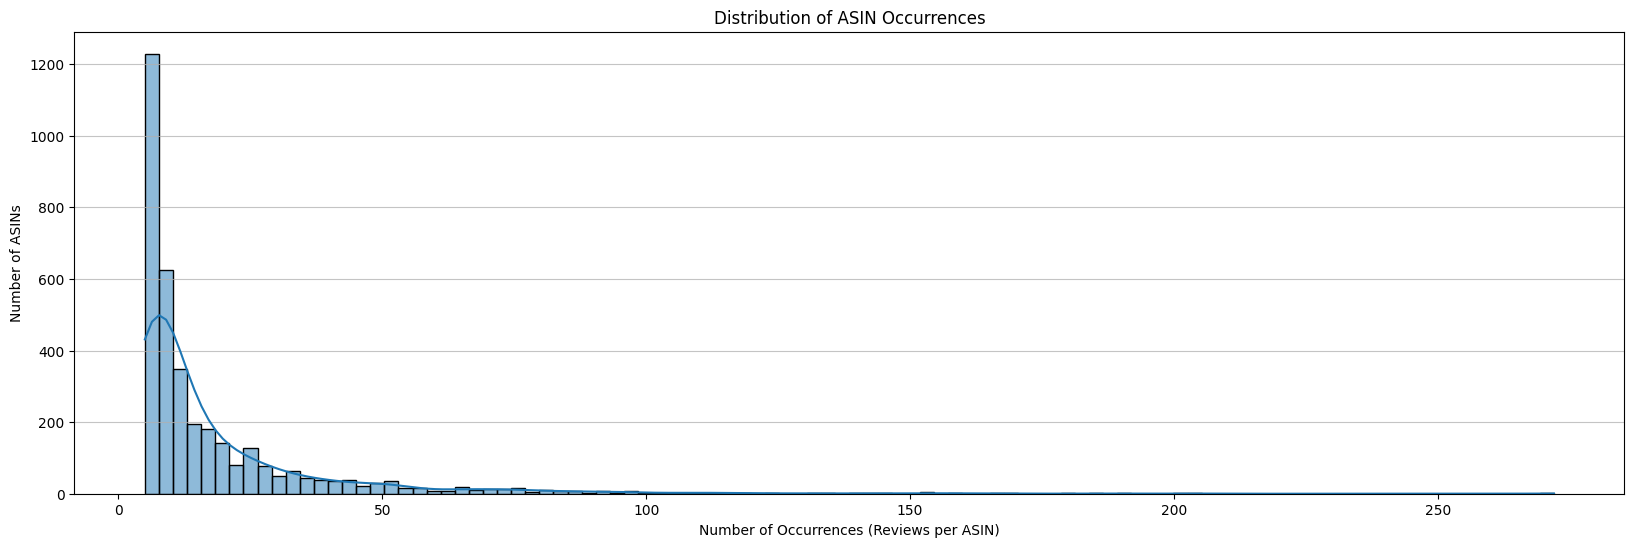

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

asin_review_counts = df['asin'].value_counts()

plt.figure(figsize=(20, 6))
sns.histplot(asin_review_counts, bins=100, kde=True)
plt.title('Distribution of ASIN Occurrences')
plt.xlabel('Number of Occurrences (Reviews per ASIN)')
plt.ylabel('Number of ASINs')
plt.grid(axis='y', alpha=0.75)
plt.show()

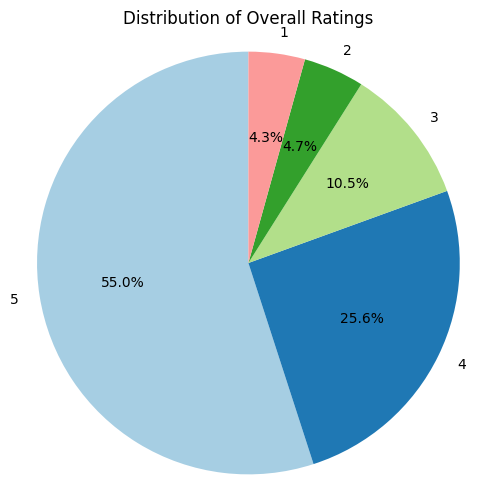

In [23]:
import matplotlib.pyplot as plt

overall_counts = df['overall'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(overall_counts, labels=overall_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Distribution of Overall Ratings')
plt.axis('equal')
plt.show()

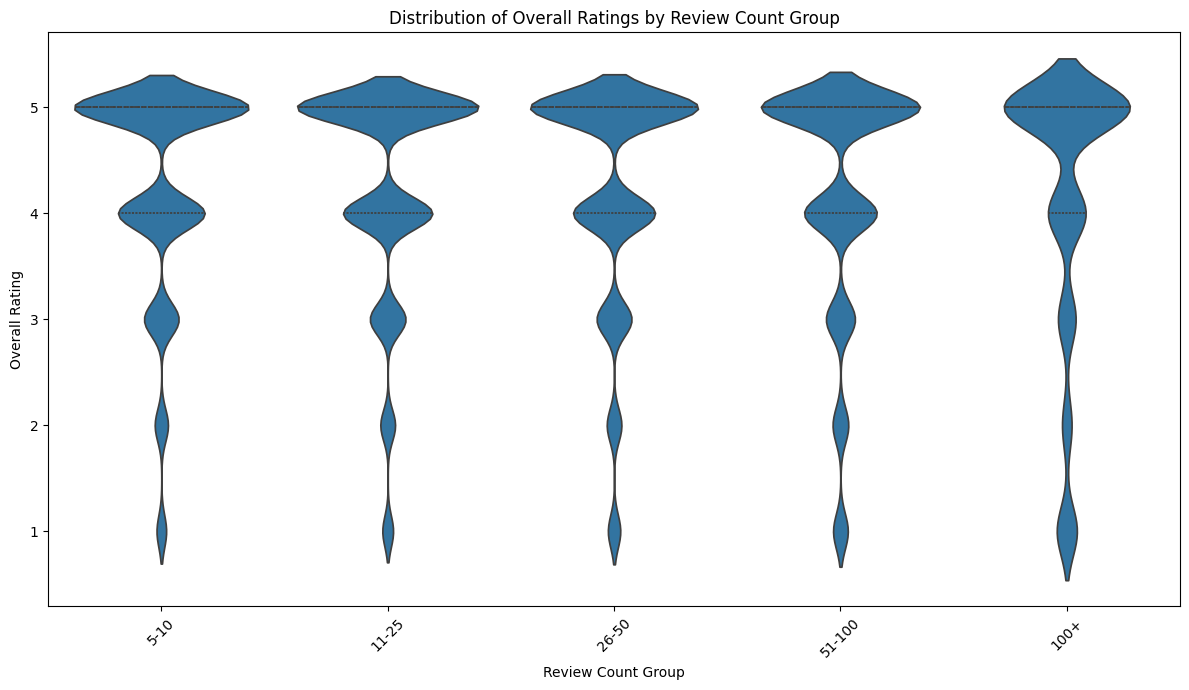

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculation
df['asin_review_count'] = df['asin'].map(asin_review_counts)
bins = [0, 10, 25, 50, 100, float('inf')]
labels = ['5-10', '11-25', '26-50', '51-100', '100+']
df['review_count_group'] = pd.cut(df['asin_review_count'], bins=bins, labels=labels, right=True, include_lowest=True)

# Plot
plt.figure(figsize=(12, 7))
sns.violinplot(x='review_count_group', y='overall', data=df, inner='quartile', order=labels)
plt.title('Distribution of Overall Ratings by Review Count Group')
plt.xlabel('Review Count Group')
plt.ylabel('Overall Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As we can see, the distribution of the review dataset is really bias in positive feedbacks, even though we observed a recognizable increase in the 1-star feedbacks when the number of reviews increases. That may show that most of sold product are good, but just for some popular one can have broader range of customer and then it will receive broader range of feedbacks from different perspectives. Or it can be a consequence of a hype, as the product go viral quickly, and can not adapt with new and non-initial target audiences

# Preprocessing and vectorizing

As shown in the data exploration stage, the distribution stay quite same even when the product scale to broader range of audiences.So, the hidden intentions may not affect much on the sentiment analysis phase, then we decide to ignore the asin ID, and then concatenate the review with the summary.

In [25]:
df['reviewText'] = df['summary'] + ". " + df['reviewText']
df = df.drop(columns=['asin', 'asin_review_count', 'review_count_group', 'summary'])
df['reviewText'] =  df['reviewText'].str.lower()
df.head()

,reviewText,overall
0,enya's last great album. it's hard to believe ...,5
1,enya at her most elegant. a clasically-styled ...,5
2,the best so far. i never thought enya would re...,5
3,ireland produces good music.. this is the thir...,5
4,"4.5; music to dream to. enya, despite being a ...",4


The reviewText serves as the input, and overall serves as the label for that input - 5 stars. We then randomly select samples to train and test sets.

In [26]:
df['reviewText'][0]

'enya\'s last great album. it\'s hard to believe "memory of trees" came out 11 years ago;it has held up well over the passage of time.it\'s enya\'s last great album before the new age/pop of "amarantine" and "day without rain." back in 1995,enya still had her creative spark,her own voice.i agree with the reviewer who said that this is her saddest album;it is melancholy,bittersweet,from the opening title song."memory of trees" is elegaic&majestic.;"pax deorum" sounds like it is from a requiem mass,it is a dark threnody.unlike the reviewer who said that this has a "disconcerting" blend of spirituality&sensuality;,i don\'t find it disconcerting at all."anywhere is" is a hopeful song,looking to possibilities."hope has a place" is about love,but it is up to the listener to decide if it is romantic,platonic,etc.i\'ve always had a soft spot for this song."on my way home" is a triumphant ending about return.this is truly a masterpiece of new age music,a must for any enya fan!'

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['reviewText'])

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['reviewText'], df['overall'], test_size = 0.3, random_state=42, stratify=df['overall'])

In [29]:
# Tranform the data into tf-idf vector
X_tfidf_train_sparse = tfidf_vectorizer.fit_transform(X_train)
X_tfidf_test_sparse = tfidf_vectorizer.transform(X_test)

I use SMOTE - Synthetic Minority Over-sampling Technique to address heavily imbalance dataset

In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_tfidf_train_sparse, y_train = smote.fit_resample(X_tfidf_train_sparse, y_train)

print("Number of samples:", X_tfidf_train_sparse.shape[0] + X_tfidf_test_sparse.shape[0])
print("Resampled class distribution:\n", y_train.value_counts())
print("Number of vocabulary:", X_tfidf_train_sparse.shape[1])

Number of samples: 143942
Resampled class distribution:
 overall
5    24906
3    24906
4    24906
2    24906
1    24906
Name: count, dtype: int64
Number of vocabulary: 97769


# Building models

Treat all classes equally, as the dataset is heavily bias on positive feedbacks

In [31]:
from sklearn.naive_bayes import MultinomialNB

def train_MNB_model(X_train_transformed, X_test_transformed):
  mnb = MultinomialNB(class_prior=[0.2, 0.2, 0.2, 0.2, 0.2])
  mnb.fit(X_train_transformed, y_train)
  y_pred = mnb.predict(X_test_transformed)

  return y_pred

y_MNB_pred = train_MNB_model(X_tfidf_train_sparse, X_tfidf_test_sparse)


In [32]:
from sklearn.linear_model import LogisticRegression

def train_LR_model(X_train_transformed, X_test_transformed):
  model_lr = LogisticRegression(class_weight='balanced', max_iter=1000) # Increased max_iter for better convergence
  model_lr.fit(X_train_transformed, y_train)
  y_pred = model_lr.predict(X_test_transformed)

  return y_pred

y_LR_pred = train_LR_model(X_tfidf_train_sparse, X_tfidf_test_sparse)

In [33]:
from sklearn.svm import LinearSVC

def train_SVM_model(X_train_transformed, X_test_transformed):
  model_svm = LinearSVC(class_weight='balanced')
  model_svm.fit(X_train_transformed, y_train)
  y_pred = model_svm.predict(X_test_transformed)

  return y_pred

y_SVM_pred = train_SVM_model(X_tfidf_train_sparse, X_tfidf_test_sparse)

# Evaluation

Quadratic is a classification measurement for ordinal data - order of data matters. It penalizes heavier on the larger differences between the prediction and the acutal data. The formula of the metric is like this:

$$k = 1 - \frac{\sum_{i,j} w_{i,j} O_{i,j}}{\sum_{i,j} w_{i,j} E_{i,j}}$$

$w_{i,j} = \frac{(i-j)^2}{(N-1)^2}$ represents the differences between predicted and actual data.

$O_{i,j}$ represents the confusion matrix.

$E_{i,j}$ represents the expected matrix, calculated by the normalized cross-product between two predicted and actual vectors.

To evaluate, consider the value of k:

    k = 1: ideal (complete aggrement)
    k > 0: better than random choice
    k = 0: equal as random choice
    k < 0: worse than random choice




About the mean absolute error, it represents the expected differences between the predicted and actual data. For example, for a 2-star review, it is predicted as $2-ϵ$ or $2+ϵ$ most of the time. The smaller the error is, the better the models are.

In [34]:
from sklearn.metrics import classification_report, cohen_kappa_score
from sklearn.metrics import mean_absolute_error, mean_squared_error

def extended_eval(y_true, y_pred, model_name):
    print(f"\n--------------- Extended Evaluation for {model_name} ---------------")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4, labels=[1, 2, 3, 4, 5]))

    # MAE and MSE
    mae = mean_absolute_error(y_test, y_pred)
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean Squared Error (MSE): {mse:.4f}")

    # Quadratic Weighted Kappa is suitable for ordinal classification
    kappa_score = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    print(f"Quadratic Weighted Kappa: {kappa_score:.4f}")

# Evaluate all models with extended metrics
extended_eval(y_test, y_MNB_pred, "Multinomial Naive Bayes")
extended_eval(y_test, y_LR_pred, "Logistic Regression")
extended_eval(y_test, y_SVM_pred, "Support Vector Machine")


--------------- Extended Evaluation for Multinomial Naive Bayes ---------------

Classification Report:
              precision    recall  f1-score   support

           1     0.3497    0.6057    0.4434       837
           2     0.1565    0.3311    0.2125       903
           3     0.2421    0.4109    0.3047      2037
           4     0.3751    0.4606    0.4135      4961
           5     0.8201    0.4996    0.6209     10674

    accuracy                         0.4771     19412
   macro avg     0.3887    0.4616    0.3990     19412
weighted avg     0.5946    0.4771    0.5081     19412

Mean Absolute Error (MAE): 0.7983
Mean Squared Error (MSE): 1.5993
Quadratic Weighted Kappa: 0.4533

--------------- Extended Evaluation for Logistic Regression ---------------

Classification Report:
              precision    recall  f1-score   support

           1     0.5222    0.6607    0.5833       837
           2     0.3031    0.3621    0.3300       903
           3     0.3725    0.4374    0.402

### Test Cases for Model Performance (Logistic Regression)

In [40]:
import numpy as np

sample_indices = np.random.choice(X_test.index, 5, replace=False)

print("\n--- Sample Test Cases (Logistic Regression) ---")

for i, idx in enumerate(sample_indices):
    original_review = X_test.loc[idx]
    actual_rating = y_test.loc[idx]
    test_index_position = list(X_test.index).index(idx)
    predicted_rating = y_LR_pred[test_index_position]

    print(f"\n--- Test Case {i+1} ---")
    print(f"Review: {original_review[:500]}...")
    print(f"Actual Rating: {actual_rating}")
    print(f"Predicted Rating: {predicted_rating}")
    print("----------------------")


--- Sample Test Cases (Logistic Regression) ---

--- Test Case 1 ---
Review: ugh!. how could norah, of all people, let us down like that? me and my wife were enourmous fans of this blossoming young artist's debut album, and anxiously awaited the next one. but this is crap! it is pure country! that's okay, i guess, but this is taking it too far. we were hoping for another come away with me.it makes me sick to think that artists like norah don't give a hoot about their fans. they just do what they wanna do. me and my wife feel like metallica fans must have felt when the ba...
Actual Rating: 1
Predicted Rating: 1
----------------------

--- Test Case 2 ---
Review: a mixed bag of what you want. natalie, the latest mariah carey-wannabe (which there have been many of), decided to make her own album. as of passing times there have been numerous mariah carey-wannabes that fail, but luckily, natalie has the talent, and is on her way to become the next mariah carey.natalie's voice is soft, nice

## Conclusion

In addition, all models performs badly on classifying 2-3 stars reviews, as seen in f1-score in classificaiton report. This is mainly because those reviews often contains both positive and negative feedbacks in the review. So, the model hard to classify it perfectly. However, it is not always the case. Sometimes, we only need a nearly-correct predictions of rating int he review. A 2-star review is quite near to the 1-star review, but it is also quite similar to 3-star review. So, we should consider the performance on other metrics, such as MAE, MSE Quadratic Weighted Kappa.

Considering other metrics, It seems like the models perform quite good. For example, Logistic Regression model predict the rating with just ~0.5 error. The Quadratic Weighted Kappa scores are also quite good, from 0.45 to 0.67.

There is another hard problem in those tasks that is the reviews may not always contains straighforward words representing the true meaning of those reviewers. We can see that in some random testcases. Some reviews may only contains "dirty" words, but give really high rating for the music. Those type of problems is considered as cultural, behavioural problems, and these are reall hard to handle.

In conclusion, the Logistic Regression gain best performance, then Support Vector Machine, then Multinomial Naive Bayes.

I also tried to improve the performance by introducing bigram, and experience with different set of hyperparameter. But, the result did not change much even comsuming more resources.